# Introduction

In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [19]:
import seaborn as sns

### Time Range
- First period: 2016-06-30, 2016-12-31, **2017-06-30**, 2017-12-31, 2018-06-30, 2019-06-30
- Second period: 2022-06-30, 2022-12-31, **2023-06-30**, 2023-12-31, 2024-06-30, 2025-06-30

## Camden's analysis in 2017
基准分析：2016-06-30（重估前）\
2017年4月数据（重估刚实施）

In [22]:
camden_17 = pd.read_csv('data_source/period-2010-to-2017-E09000007-camden.csv')
camden_17.columns

Index(['filter_period', 'billing_authority_name', 'geocode', 'uarn',
       'billing_reference', 'account_name', 'account_start_date',
       'searchable_address', 'postcode_id', 'geometry', 'occupation_state',
       'occupation_date', 'category_id', 'primary_description',
       'category_subgroup', 'category_group', 'rates_payable',
       'rateable_value', 'total_floor_area', 'unit_of_measure', 'from_date',
       'record_date', 'series', 'epoch'],
      dtype='object')

In [32]:
# 基本数据清理
camden_17N = camden_17[camden_17['rateable_value'] > 0]  # 移除异常值
camden_17N = camden_17N.dropna(subset=['rateable_value']) # 移除rateable_value为NaN的记录

In [33]:
# 将 'geometry' 列从 WKB 字符串转换为 Shapely 几何对象
from shapely import wkb

camden_17N['geom'] = camden_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_17N.head(3)

,filter_period,billing_authority_name,geocode,uarn,billing_reference,account_name,account_start_date,searchable_address,postcode_id,geometry,...,category_group,rates_payable,rateable_value,total_floor_area,unit_of_measure,from_date,record_date,series,epoch,geom
0,2016-06-30,Camden,E09000007,1072063,00434000220006,NaN,NaN,"2-6, ADAMSON ROAD, LONDON, NW3 3HP",NW3 3HP,0101000000a60c1cd0d215c6bf92ae997cb3c54940,...,LEISURE,NaN,117000.0,NaN,NaN,2010-04-01,NaN,2010,21,POINT (-0.172541 51.54454)
1,2016-06-30,Camden,E09000007,1405063,00577090020012,NaN,NaN,"1, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,OFFICE,NaN,18750.0,79.6,NIA,2010-04-01,NaN,2010,21,POINT (-0.153985 51.54407)
4,2016-06-30,Camden,E09000007,1409063,00577090020065,NaN,NaN,"6, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,RETAIL,NaN,10000.0,33.6,NIA,2010-04-01,NaN,2010,21,POINT (-0.153985 51.54407)


### 基准分布可视化
- 设置分析范围

方法一：\
2016-06-30分为二类：小于或等于15,000；大于15,000 \
查看到2017-06-30(重新划定RV)是否部分大于15，000➡️导致其的经营状态产生了变化

In [34]:
#查找2016-06-30的数据:2010 0021
camden_17_baseline = camden_17N[(camden_17N['series'] == 2010) & (camden_17['epoch'] == 21)]
camden_17_baseline.head(5)

/tmp/ipykernel_178/4116531592.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  camden_17_baseline = camden_17N[(camden_17N['series'] == 2010) & (camden_17['epoch'] == 21)]


,filter_period,billing_authority_name,geocode,uarn,billing_reference,account_name,account_start_date,searchable_address,postcode_id,geometry,...,category_group,rates_payable,rateable_value,total_floor_area,unit_of_measure,from_date,record_date,series,epoch,geom
0,2016-06-30,Camden,E09000007,1072063,00434000220006,NaN,NaN,"2-6, ADAMSON ROAD, LONDON, NW3 3HP",NW3 3HP,0101000000a60c1cd0d215c6bf92ae997cb3c54940,...,LEISURE,NaN,117000.0,NaN,NaN,2010-04-01,NaN,2010,21,POINT (-0.172541 51.54454)
1,2016-06-30,Camden,E09000007,1405063,00577090020012,NaN,NaN,"1, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,OFFICE,NaN,18750.0,79.6,NIA,2010-04-01,NaN,2010,21,POINT (-0.153985 51.54407)
4,2016-06-30,Camden,E09000007,1409063,00577090020065,NaN,NaN,"6, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,RETAIL,NaN,10000.0,33.6,NIA,2010-04-01,NaN,2010,21,POINT (-0.153985 51.54407)
5,2016-06-30,Camden,E09000007,2659063,00765003035019,NaN,NaN,"THE WHITE HOUSE, ALBANY STREET, LONDON, NW1 3UT",NW1 3UT,01010000007521567f8461c2bf8121ab5b3dc34940,...,LEISURE,NaN,4000000.0,NaN,NaN,2013-01-15,NaN,2010,21,POINT (-0.143601 51.52531)
6,2016-06-30,Camden,E09000007,3497063,00793011319991,NaN,NaN,"ST ALOYSIUS SCHOOL 113, ALDENHAM STREET, LONDO...",NW1 1PS,0101000000ec33677dca31c1bf23f3c81f0cc44940,...,OTHER,NaN,31500.0,NaN,NaN,2016-06-30,NaN,2010,21,POINT (-0.134332 51.53162)


In [35]:
#查找重估后 2017-06-30的数据:2017 0002
camden_17_re = camden_17N[(camden_17N['series'] == 2017) & (camden_17['epoch'] == 2)]
camden_17_re.head(5)

/tmp/ipykernel_178/2147599515.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  camden_17_re = camden_17N[(camden_17N['series'] == 2017) & (camden_17['epoch'] == 2)]


,filter_period,billing_authority_name,geocode,uarn,billing_reference,account_name,account_start_date,searchable_address,postcode_id,geometry,...,category_group,rates_payable,rateable_value,total_floor_area,unit_of_measure,from_date,record_date,series,epoch,geom
50012,2017-06-30,NaN,E09000007,1072063,00434000220006,NaN,NaN,"2-6, ADAMSON ROAD, LONDON, NW3 3HP",NW3 3HP,0101000000a60c1cd0d215c6bf92ae997cb3c54940,...,LEISURE,NaN,170250.0,NaN,NaN,2017-04-01,NaN,2017,2,POINT (-0.172541 51.54454)
50013,2017-06-30,NaN,E09000007,1405063,00577090020012,NaN,NaN,"1, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,OFFICE,NaN,18750.0,NaN,NaN,2017-04-01,NaN,2017,2,POINT (-0.153985 51.54407)
50014,2017-06-30,NaN,E09000007,1409063,00577090020065,NaN,NaN,"6, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,RETAIL,NaN,10000.0,NaN,NaN,2017-04-01,NaN,2017,2,POINT (-0.153985 51.54407)
50015,2017-06-30,NaN,E09000007,2659063,00765003035019,NaN,NaN,"THE WHITE HOUSE, ALBANY STREET, LONDON, NW1 3UT",NW1 3UT,01010000007521567f8461c2bf8121ab5b3dc34940,...,LEISURE,NaN,5170000.0,NaN,NaN,2017-04-01,NaN,2017,2,POINT (-0.143601 51.52531)
50016,2017-06-30,NaN,E09000007,3497063,00793011319991,NaN,NaN,"ST ALOYSIUS SCHOOL 113, ALDENHAM STREET, LONDO...",NW1 1PS,0101000000ec33677dca31c1bf23f3c81f0cc44940,...,OTHER,NaN,59500.0,NaN,NaN,2017-04-01,NaN,2017,2,POINT (-0.134332 51.53162)


In [37]:
# 设置分析范围（重点关注门槛附近）
threshold_1 = 15000  # 第一个门槛
threshold_2 = 51000  # 第二个门槛

In [ ]:
# 分组:≤15,000; >15,000
low_value = camden_20160630[camden_20160630['rateable_value'] <= 15000]
high_value = camden_20160630[camden_20160630['rateable_value'] > 15000]

camden_20160630.head(3)

,filter_period,billing_authority_name,geocode,uarn,billing_reference,account_name,account_start_date,searchable_address,postcode_id,geometry,...,category_group,rates_payable,rateable_value,total_floor_area,unit_of_measure,from_date,record_date,series,epoch,geom
0,2016-06-30,Camden,E09000007,1072063,00434000220006,NaN,NaN,"2-6, ADAMSON ROAD, LONDON, NW3 3HP",NW3 3HP,0101000000a60c1cd0d215c6bf92ae997cb3c54940,...,LEISURE,NaN,117000.0,NaN,NaN,2010-04-01,NaN,2010,21,POINT (-0.172541 51.54454)
1,2016-06-30,Camden,E09000007,1405063,00577090020012,NaN,NaN,"1, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,OFFICE,NaN,18750.0,79.6,NIA,2010-04-01,NaN,2010,21,POINT (-0.153985 51.54407)
2,2016-06-30,Camden,E09000007,1406063,00577090020027,NaN,NaN,"2, CHALK FARM PARADE, ADELAIDE ROAD, LONDON, N...",NW3 2BN,01010000002f8b89cdc7b5c3bf0b5ef415a4c54940,...,RETAIL,NaN,NaN,51.1,NIA,2012-02-22,NaN,2010,21,POINT (-0.153985 51.54407)


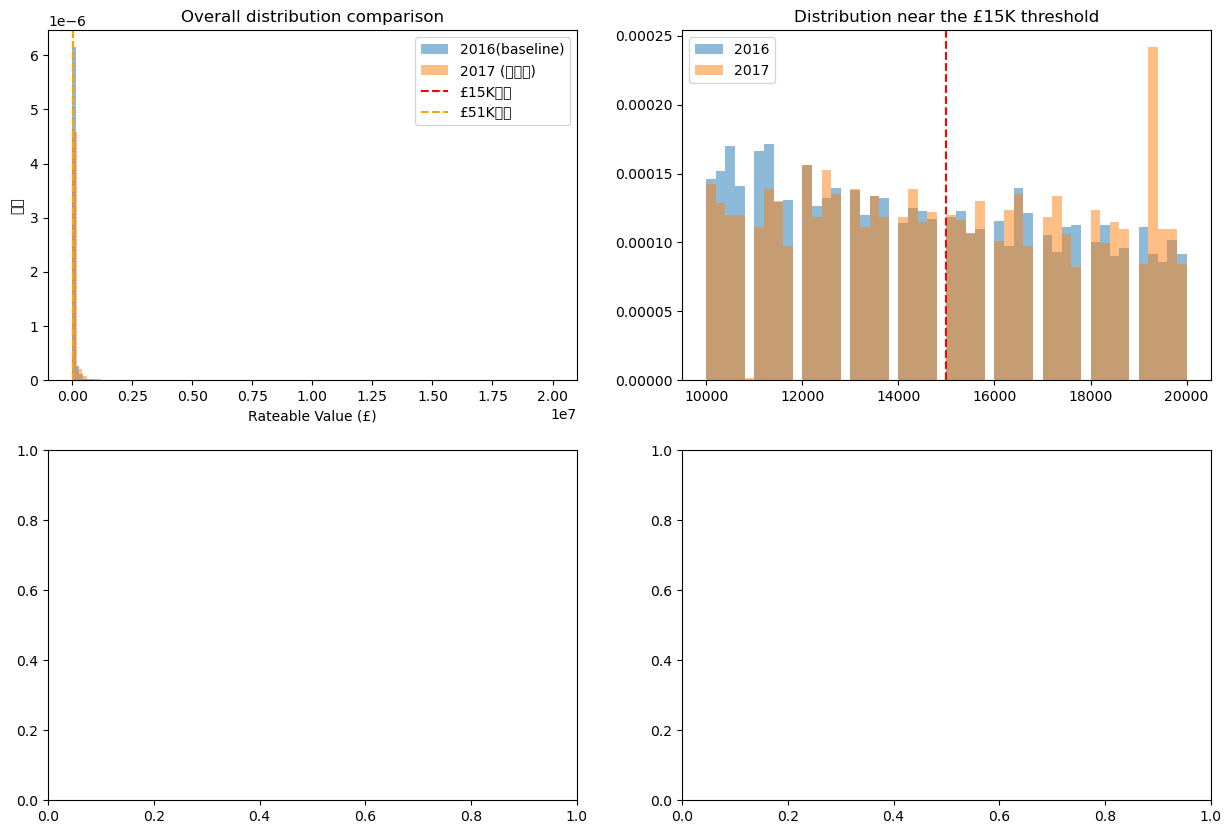

In [44]:
# 创建分布图
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 整体分布对比
axes[0,0].hist(camden_17_baseline['rateable_value'], bins=100, alpha=0.5, 
               label='2016(baseline)', density=True)
axes[0,0].hist(camden_17_re['rateable_value'], bins=100, alpha=0.5,
               label='2017 (重估后)', density=True)
axes[0,0].axvline(threshold_1, color='red', linestyle='--', label='£15K门槛')
axes[0,0].axvline(threshold_2, color='orange', linestyle='--', label='£51K门槛')
axes[0,0].set_xlabel('Rateable Value (£)')
axes[0,0].set_ylabel('密度')
axes[0,0].set_title('Overall distribution comparison')
axes[0,0].legend()

# 2. 第一个门槛附近的详细分布
range_1 = (10000, 20000)
camden_17_baseline_zoom1 = camden_17_baseline[(camden_17_baseline['rateable_value'] >= range_1[0]) & (camden_17_baseline['rateable_value'] <= range_1[1])]
camden_17_re_zoom1 = camden_17_re[(camden_17_re['rateable_value'] >= range_1[0]) & (camden_17_re['rateable_value'] <= range_1[1])]

axes[0,1].hist(camden_17_baseline_zoom1['rateable_value'], bins=50, alpha=0.5, 
               label='2016', density=True)
axes[0,1].hist(camden_17_re_zoom1['rateable_value'], bins=50, alpha=0.5, 
               label='2017', density=True)
axes[0,1].axvline(threshold_1, color='red', linestyle='--')
axes[0,1].set_title('Distribution near the £15K threshold')
axes[0,1].legend()

/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 20225 (\N{CJK UNIFIED IDEOGRAPH-4F01}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_178/964786612.py:47: UserWarning: Glyph 27099 (\N{CJK UNIFIED IDEOGRAPH-69DB}) missing from current font.
  plt.tight_layout()
/tmp/i

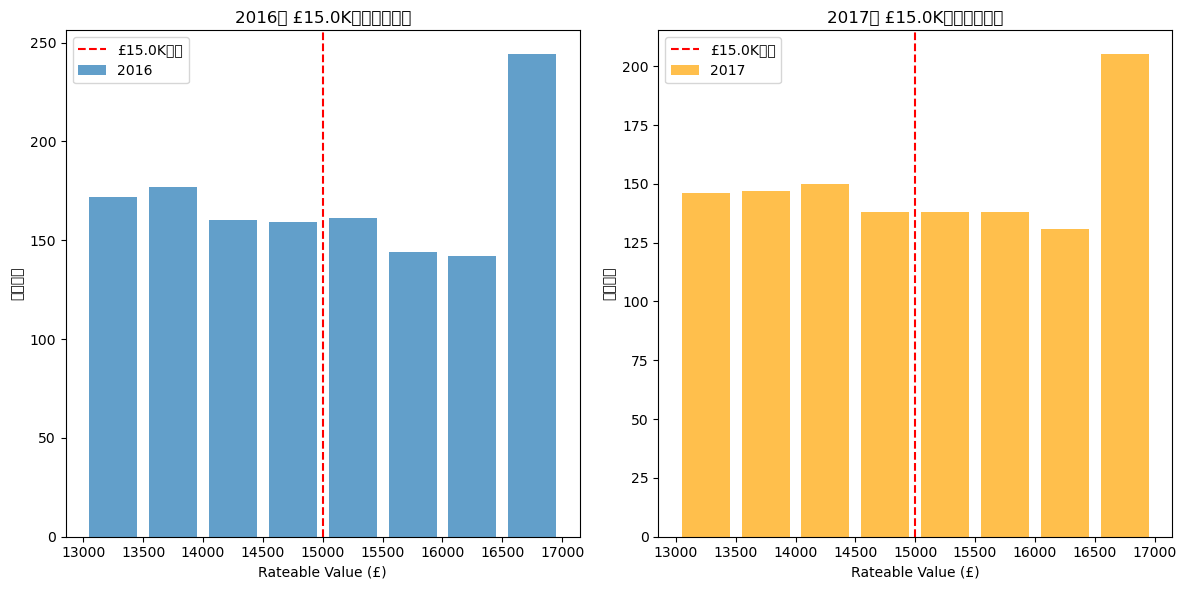

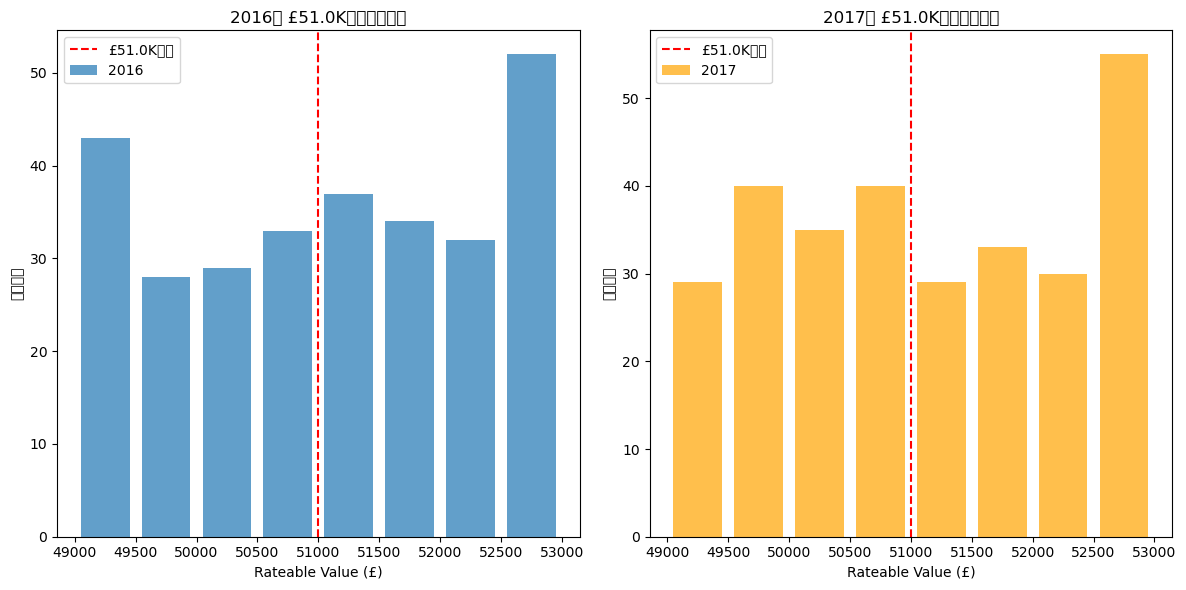

In [45]:
# 创建分箱来检测"bump"
def analyze_threshold_distortion(df, threshold, window=2000, bin_size=500):
    """
    分析门槛附近的分布扭曲
    threshold: 门槛值
    window: 分析窗口大小
    bin_size: 分箱大小
    """
    # 选择门槛附近的数据
    mask = (df['rateable_value'] >= threshold - window) & \
           (df['rateable_value'] <= threshold + window)
    data = df[mask]['rateable_value']
    
    # 创建分箱
    bins = np.arange(threshold - window, threshold + window + bin_size, bin_size)
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return bin_centers, counts

# 分析两个门槛
thresholds = [15000, 51000]
for i, threshold in enumerate(thresholds):
    # 2016年基准分析
    bins_2016, counts_2016 = analyze_threshold_distortion(camden_17_baseline, threshold)
    bins_2017, counts_2017 = analyze_threshold_distortion(camden_17_re, threshold)
    
    # 可视化
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.bar(bins_2016, counts_2016, width=400, alpha=0.7, label='2016')
    plt.axvline(threshold, color='red', linestyle='--', label=f'£{threshold/1000}K门槛')
    plt.xlabel('Rateable Value (£)')
    plt.ylabel('企业数量')
    plt.title(f'2016年 £{threshold/1000}K门槛附近分布')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.bar(bins_2017, counts_2017, width=400, alpha=0.7, label='2017', color='orange')
    plt.axvline(threshold, color='red', linestyle='--', label=f'£{threshold/1000}K门槛')
    plt.xlabel('Rateable Value (£)')
    plt.ylabel('企业数量')
    plt.title(f'2017年 £{threshold/1000}K门槛附近分布')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [46]:
def test_bunching_effect(df, threshold, pre_window=1000, post_window=1000):
    """
    检测门槛处的bunching效应
    """
    # 门槛前后的区间
    before_threshold = df[(df['rateable_value'] >= threshold - pre_window) & 
                         (df['rateable_value'] < threshold)]
    after_threshold = df[(df['rateable_value'] >= threshold) & 
                        (df['rateable_value'] <= threshold + post_window)]
    
    # 计算密度
    before_count = len(before_threshold)
    after_count = len(after_threshold)
    
    # 期望比例（假设均匀分布）
    expected_ratio = 1.0
    actual_ratio = before_count / max(after_count, 1)
    
    print(f"门槛 £{threshold:,}")
    print(f"门槛前企业数: {before_count}")
    print(f"门槛后企业数: {after_count}")
    print(f"实际比例: {actual_ratio:.2f}")
    print(f"扭曲程度: {(actual_ratio - expected_ratio) * 100:.1f}%")
    print("-" * 40)
    
    return before_count, after_count, actual_ratio

# 对比2016年和2017年的bunching效应
print("=== 2016年基准分析 ===")
for threshold in [15000, 51000]:
    test_bunching_effect(camden_17_baseline, threshold)

print("\n=== 2017年重估后分析 ===")
for threshold in [15000, 51000]:
    test_bunching_effect(camden_17_re, threshold)

=== 2016年基准分析 ===
门槛 £15,000
门槛前企业数: 319
门槛后企业数: 382
实际比例: 0.84
扭曲程度: -16.5%
----------------------------------------
门槛 £51,000
门槛前企业数: 62
门槛后企业数: 103
实际比例: 0.60
扭曲程度: -39.8%
----------------------------------------

=== 2017年重估后分析 ===
门槛 £15,000
门槛前企业数: 288
门槛后企业数: 335
实际比例: 0.86
扭曲程度: -14.0%
----------------------------------------
门槛 £51,000
门槛前企业数: 75
门槛后企业数: 92
实际比例: 0.82
扭曲程度: -18.5%
----------------------------------------


In [47]:
# 计算分布的关键统计量
def distribution_summary(df, name):
    rv = df['rateable_value']
    
    summary = {
        'year': name,
        'total_businesses': len(df),
        'below_15k': len(df[rv < 15000]),
        'between_15k_51k': len(df[(rv >= 15000) & (rv < 51000)]),
        'above_51k': len(df[rv >= 51000]),
        'mean_value': rv.mean(),
        'median_value': rv.median()
    }
    
    return summary

# 生成对比报告
summary_2016 = distribution_summary(camden_17_baseline, '2016')
summary_2017 = distribution_summary(camden_17_re, '2017')

comparison_df = pd.DataFrame([summary_2016, summary_2017])
print(comparison_df)

   year  total_businesses  below_15k  between_15k_51k  above_51k  \
0  2016             18328       9110             5239       3979   
1  2017             17549       7310             5369       4870   

     mean_value  median_value  
0  66911.570166       15000.0  
1  91231.125819       20250.0  


In [65]:
time_points = {
    '2016-06-30': '重估前12个月',
    '2016-12-31': '重估前6个月', 
    '2017-06-30': '重估实施时',
    '2017-12-31': '重估后6个月',
    '2018-06-30': '重估后12个月',
    '2019-06-30': '重估后24个月'
}
# 提取所有时间点的数据
def extract_all_timepoints(df):
    timepoints = {
        'pre_12m': df[(df['series'] == 2010) & (df['epoch'] == 21)],
        'pre_6m': df[(df['series'] == 2010) & (df['epoch'] == 23)],
        'revaluation': df[(df['series'] == 2017) & (df['epoch'] == 2)],
        'post_6m': df[(df['series'] == 2017) & (df['epoch'] == 4)],
        'post_12m': df[(df['series'] == 2017) & (df['epoch'] == 7)],
        'post_24m': df[(df['series'] == 2017) & (df['epoch'] == 13)]
    }
    return timepoints


In [66]:
# 动态bunching分析
def dynamic_bunching_analysis(timepoints_dict, thresholds=[15000, 51000]):
    results = []
    
    for period, df in timepoints_dict.items():
        if len(df) == 0:
            continue
            
        df_clean = df.dropna(subset=['rateable_value'])
        
        for threshold in thresholds:
            before = len(df_clean[(df_clean['rateable_value'] >= threshold-1000) & 
                                 (df_clean['rateable_value'] < threshold)])
            after = len(df_clean[(df_clean['rateable_value'] >= threshold) & 
                                (df_clean['rateable_value'] <= threshold+1000)])
            
            ratio = before / max(after, 1)
            distortion = (ratio - 1) * 100
            
            results.append({
                'period': period,
                'threshold': threshold,
                'before_count': before,
                'after_count': after,
                'ratio': ratio,
                'distortion_pct': distortion
            })
    
    return pd.DataFrame(results)

In [67]:
def track_business_survival(timepoints_dict):
    """追踪企业在不同时间点的生存状态"""
    
    # 以重估前12个月为基准
    baseline = timepoints_dict['pre_12m'].dropna(subset=['rateable_value'])
    baseline_uarns = set(baseline['uarn'])
    
    survival_data = []
    
    for period, df in timepoints_dict.items():
        if len(df) == 0:
            continue
            
        df_clean = df.dropna(subset=['rateable_value'])
        current_uarns = set(df_clean['uarn'])
        
        # 计算生存率
        survived = len(baseline_uarns & current_uarns)
        survival_rate = survived / len(baseline_uarns) * 100
        
        # 按门槛分组分析
        for threshold in [15000, 51000]:
            # 基准期在门槛附近的企业
            near_threshold = baseline[
                (baseline['rateable_value'] >= threshold-2000) & 
                (baseline['rateable_value'] <= threshold+2000)
            ]
            near_threshold_uarns = set(near_threshold['uarn'])
            
            # 这些企业在当前期的生存情况
            survived_near = len(near_threshold_uarns & current_uarns)
            survival_rate_near = survived_near / len(near_threshold_uarns) * 100 if len(near_threshold_uarns) > 0 else 0
            
            survival_data.append({
                'period': period,
                'threshold': threshold,
                'total_baseline': len(baseline_uarns),
                'near_threshold_baseline': len(near_threshold_uarns),
                'survived_total': survived,
                'survived_near_threshold': survived_near,
                'survival_rate_total': survival_rate,
                'survival_rate_near_threshold': survival_rate_near
            })
    
    return pd.DataFrame(survival_data)

In [68]:
def analyze_business_responses(timepoints_dict):
    """分析企业的应对策略"""
    
    baseline = timepoints_dict['pre_12m'].dropna(subset=['rateable_value'])
    revaluation = timepoints_dict['revaluation'].dropna(subset=['rateable_value'])
    post_12m = timepoints_dict['post_12m'].dropna(subset=['rateable_value'])
    
    # 合并数据追踪变化
    baseline_indexed = baseline.set_index('uarn')[['rateable_value', 'total_floor_area']]
    revaluation_indexed = revaluation.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_12m_indexed = post_12m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    
    # 找到连续存在的企业
    common_uarns = set(baseline_indexed.index) & set(revaluation_indexed.index) & set(post_12m_indexed.index)
    
    responses = []
    
    for uarn in common_uarns:
        base_val = baseline_indexed.loc[uarn, 'rateable_value']
        reval_val = revaluation_indexed.loc[uarn, 'rateable_value'] 
        post_val = post_12m_indexed.loc[uarn, 'rateable_value']
        
        base_area = baseline_indexed.loc[uarn, 'total_floor_area']
        post_area = post_12m_indexed.loc[uarn, 'total_floor_area']
        
        # 分类应对策略
        strategy = 'unknown'
        
        if post_val < reval_val * 0.9:  # 价值显著下降
            strategy = 'successful_appeal'
        elif post_area < base_area * 0.8:  # 面积显著减少
            strategy = 'space_reduction'
        elif abs(post_val - reval_val) < base_val * 0.1:  # 接受重估
            strategy = 'acceptance'
        
        # 判断是否受bracket creep影响
        affected_15k = (base_val < 15000 and reval_val >= 15000)
        affected_51k = (base_val < 51000 and reval_val >= 51000)
        
        responses.append({
            'uarn': uarn,
            'baseline_value': base_val,
            'revaluation_value': reval_val,
            'post_12m_value': post_val,
            'baseline_area': base_area,
            'post_12m_area': post_area,
            'strategy': strategy,
            'affected_15k_threshold': affected_15k,
            'affected_51k_threshold': affected_51k
        })
    
    return pd.DataFrame(responses)

In [ ]:
def comprehensive_analysis(df):
    """运行完整的6时间点分析"""
    
    # 1. 提取所有时间点数据
    timepoints = extract_all_timepoints(df)
    
    # 2. 动态bunching分析
    bunching_results = dynamic_bunching_analysis(timepoints)
    
    # 3. 生存轨迹分析
    survival_results = track_business_survival(timepoints)
    
    # 4. 应对策略分析
    response_results = analyze_business_responses(timepoints)
    
    return {
        'bunching': bunching_results,
        'survival': survival_results,
        'responses': response_results,
        'timepoints_data': timepoints
    }

In [ ]:
# 执行分析
results = comprehensive_analysis(camden_17N)

# 生成关键洞察
print("\n1. Bunching效应随时间的变化:")
print(results['bunching'])

print("\n2. 企业生存状况:")
print(results['survival'])

print("\n3. 企业应对策略分析:")
print(results['responses'].groupby('strategy').size())

print("\n4. 受阈值影响的企业数量:")
print(f"受15k阈值影响: {results['responses']['affected_15k_threshold'].sum()}")
print(f"受51k阈值影响: {results['responses']['affected_51k_threshold'].sum()}")


1. Bunching效应随时间的变化:
         period  threshold  before_count  after_count     ratio  \
0       pre_12m      15000           319          382  0.835079   
1       pre_12m      51000            62          103  0.601942   
2        pre_6m      15000           315          382  0.824607   
3        pre_6m      51000            62          103  0.601942   
4   revaluation      15000           288          335  0.859701   
5   revaluation      51000            75           92  0.815217   
6       post_6m      15000           308          345  0.892754   
7       post_6m      51000            74           92  0.804348   
8      post_12m      15000           309          350  0.882857   
9      post_12m      51000            76           98  0.775510   
10     post_24m      15000           315          353  0.892351   
11     post_24m      51000            79          101  0.782178   

    distortion_pct  
0       -16.492147  
1       -39.805825  
2       -17.539267  
3       -39.805825  
4